# Hydrogenic single solution Schrodinger equation

In [1]:
using Pkg;
Pkg.activate("../../SchrodingerEquationSolver");
include("../src/SchrodingerEquationSolver.jl");
import .SchrodingerEquationSolver as ses
import .ses.Grids as Grids
import .ses.Potentials as Potentials
import .ses.MathUtils as MathUtils
import .ses.Hydrogen as Hydrogen
import .ses.InitialConditions as InitialConditions
import .ses.OneDSchrodingerEquationSolver as odses
import .ses.EigenvalueFinders as EigenvalueFinders
using Plots

  Activating project at `~/Desktop/physics_coding_projects/julia/SchrodingerEquationSolver`


In [2]:
#Define parameters and produce an exponential grid.
r_max::Float64=50.0;
Z::Int64=10; #Atomic number, also used as the charge of coulomb potential.
grid= ses.Grids.exponential_grid(r_max, Z);

In [3]:
#Definition of the potentials with angular quantum number 0 
l::Int64=0;
v_colu= Potentials.coulomb_potential(Z, grid);
v_angu= Potentials.angular_potential(l, grid);
v_effe= v_colu + v_angu;

In [4]:
n::Float64=2.0; #shell level
ei= -0.5*(Z^2 / n^2); #Energy of hydrogenic atom
#Definition of initial conditions
init_valu1_fwrd, init_valu2_fwrd,
init_valu1_bwrd, init_valu2_bwrd =InitialConditions.atom(grid, ei, l);

# Solution of Schrodinger’s equation of the form 

$\frac{1}{2} \frac{d^2 u}{dr^2} + v_{effe} u = e_i u$

The solver integrates the equation from r_{min} to r_{max} (forward integration) and vice versa (backwards integration). The function returns the integrated function $u$ and the value of the merge of both forward and backwards solutions.

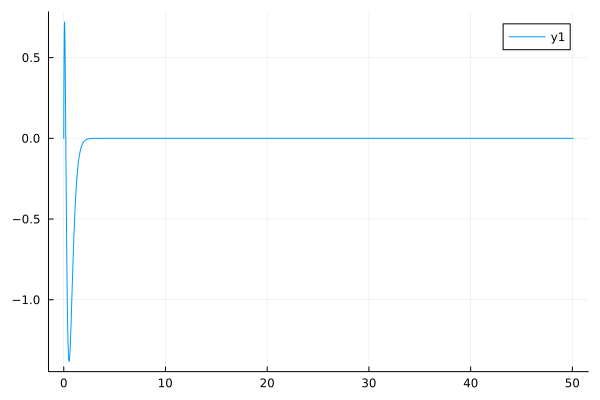

In [5]:


u_merged, merge_value, turn_pnt= odses.solver(ei,init_valu1_fwrd,init_valu2_fwrd, init_valu1_bwrd,
init_valu2_bwrd, v_effe, grid);
plot(grid, u_merged)
#plot(size=(900,400))

In [6]:
#Analyzing mergingvalue 

In [11]:
E_N=100000;
merge_values=zeros(Float64, E_N);
E_grid= Grids.uniform_grid(ei - 10.0e-8, ei + 10.0e-8, E_N);
for (i, e_i) in enumerate(E_grid)
    u_merged, merge_value, turn_pnt= odses.solver(e_i,init_valu1_fwrd,init_valu2_fwrd, init_valu1_bwrd,
    init_valu2_bwrd, v_effe, grid);
    merge_values[i]=merge_value;
end
    


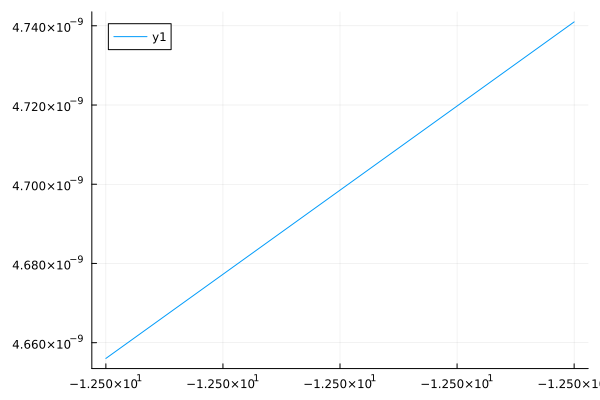

In [12]:
plot(E_grid, merge_values)

In [10]:
E_grid

1000-element Vector{Float64}:
 -12.5000001
 -12.500000099799799
 -12.5000000995996
 -12.500000099399399
 -12.500000099199198
 -12.500000098999
 -12.500000098798798
 -12.500000098598598
 -12.500000098398397
 -12.500000098198198
   ⋮
 -12.499999901601603
 -12.499999901401402
 -12.499999901201202
 -12.499999901001
 -12.499999900800802
 -12.499999900600601
 -12.4999999004004
 -12.499999900200201
 -12.4999999